In [1]:
#importing the stuff that will be needed for the analysis
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, confusion_matrix, roc_auc_score, precision_score, f1_score,
                    accuracy_score, classification_report, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [2]:
#read the dataset using pandas
dataset_test = pd.read_csv('test.csv')
dataset_training = pd.read_csv('train.csv') 

In [3]:
#showing the data to see what we're looking at
dataset_training

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,63066,45,1,0,44.35,4.0,200,0,0,1,0,0,0,1,0,0,0
1,55713,45,0,1,29.95,6.0,158,0,0,1,0,1,0,0,0,0,0
2,76757,57,1,0,30.04,8.2,260,1,0,1,0,0,0,0,0,0,1
3,47140,80,0,0,24.29,6.2,158,0,1,0,0,0,0,0,0,0,1
4,48098,21,0,0,32.92,4.8,140,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76884,4327,50,0,0,35.41,4.8,126,0,0,1,0,0,0,0,1,0,0
76885,88698,24,0,0,24.79,6.0,155,0,1,0,0,0,0,0,1,0,0
76886,54442,60,0,0,37.79,6.5,159,1,0,1,0,0,0,1,0,0,0
76887,95902,12,0,0,27.32,6.0,145,0,1,0,0,0,0,0,0,1,0


In [4]:
#scaling the data with the continuous and not the binary columns
binary_cols = [c for c in dataset_training.columns if set(pd.unique(dataset_training[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in dataset_training.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),])

train_scaled_array = preprocess.fit_transform(dataset_training) 
test_scaled_array = preprocess.transform(dataset_test)

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=dataset_training.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=dataset_test.index)

In [5]:
#set male and female train and testing
#also dropping irrelevant columns
male_train   = train_scaled[train_scaled['male'] == 1][['age', 'bmi','blood_glucose_level','hypertension', 'heart_disease','diabetes']]
male_test    = test_scaled[test_scaled['male'] == 1][['age', 'bmi','blood_glucose_level','hypertension','heart_disease','diabetes']]
female_train = train_scaled[train_scaled['female'] == 1][['age', 'bmi','blood_glucose_level','hypertension','heart_disease','diabetes']]
female_test  = test_scaled[test_scaled['female'] == 1][['age', 'bmi','blood_glucose_level','hypertension','heart_disease','diabetes']]

print("Male shapes:", male_train.shape, male_test.shape)
print("Female shapes:", female_train.shape, female_test.shape)

Male shapes: (31881, 6) (8071, 6)
Female shapes: (44994, 6) (11148, 6)


In [6]:
#example of the data after running prev section
female_train.head()

,age,bmi,blood_glucose_level,hypertension,heart_disease,diabetes
3,1.697407,-0.447605,0.486562,0.0,0.0,0.0
4,-0.926226,0.829736,0.045817,0.0,0.0,0.0
5,0.896976,2.379420,0.511048,0.0,0.0,0.0
7,0.318888,-0.563055,-0.199042,0.0,0.0,0.0
8,1.652938,0.835657,0.045817,0.0,0.0,0.0


In [7]:
#set x and y test and train for both genders. we should have 8 variables
X_male_train = male_train.drop(['diabetes'], axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(['diabetes'], axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(['diabetes'], axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(['diabetes'], axis = 1)
y_female_test  = female_test['diabetes']

In [8]:
print(y_female_test.value_counts())
print(y_female_train.value_counts())
print(y_male_test.value_counts())
print(y_male_train.value_counts())

diabetes
0.0    10259
1.0      889
Name: count, dtype: int64
diabetes
0.0    41436
1.0     3558
Name: count, dtype: int64
diabetes
0.0    7242
1.0     829
Name: count, dtype: int64
diabetes
0.0    28675
1.0     3206
Name: count, dtype: int64


In [9]:
#logisitc regression function, basic approach
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

LogisticRegression()

Females:

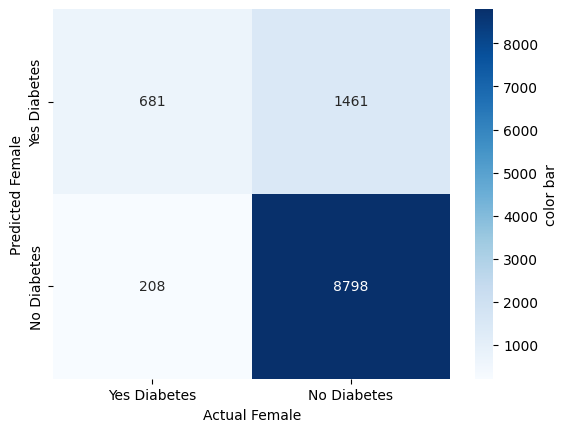


              precision    recall  f1-score   support

 No Diabetes       0.98      0.86      0.91     10259
    Diabetes       0.32      0.77      0.45       889

    accuracy                           0.85     11148
   macro avg       0.65      0.81      0.68     11148
weighted avg       0.92      0.85      0.88     11148

                                0
Accuracy                 0.850287
Sensitivity              0.766029
Specificity              0.857588
AUC-ROC                  0.910092
Precision (No Diabetes)  0.976904
F1-Score (No Diabetes)   0.913366
Precision (Diabetes)     0.317927
F1-Score (Diabetes)      0.449357



In [10]:
#metrics for females such as confusion matrix and classification report

#y_pred = lr_female.predict(X_female_test)
#y_prob = lr_female.predict_proba(X_female_test)[:,1]

#setting threshold for optimal performance
y_prob = lr_female.predict_proba(X_female_test)[:, 1]
threshold = 0.1
y_pred = (y_prob > threshold).astype(int)

#function calling for metrics
auc_f = roc_auc_score(y_female_test, y_prob)
cm_f = confusion_matrix(y_female_test, y_pred,labels=[1, 0])
sensitivity = recall_score(y_female_test, y_pred)
specificity = recall_score(y_female_test, y_pred, pos_label=0)

#generate heatmap for the confusion matrix using seaborn
sns.heatmap(cm_f.T, cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.xlabel("Actual Female")
plt.ylabel("Predicted Female")
#plt.savefig("05: Heatmap confusion matrix for Females")
plt.show()

print()

#classification report giving metrics like sensitivity and specificity
print(classification_report(y_female_test, y_pred, target_names=['No Diabetes','Diabetes']))

metrics_summary = {
    'Accuracy': accuracy_score(y_female_test, y_pred),
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc_f,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df_f = pd.DataFrame([metrics_summary])
print(metrics_df_f.T)
print()

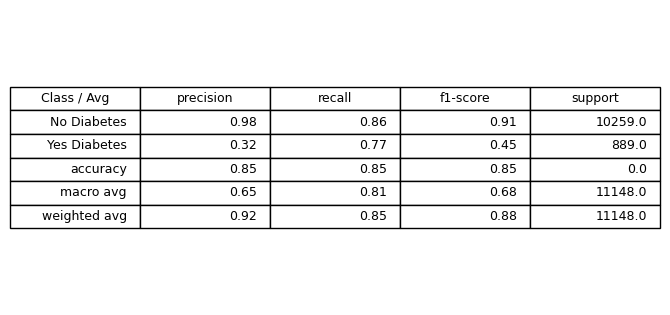

In [11]:
#classification report for females for better presentable
report = classification_report(
    y_female_test, y_pred,
    target_names=['No Diabetes', 'Yes Diabetes'],
    output_dict=True
)
df = pd.DataFrame(report).T

row_order = ['No Diabetes', 'Yes Diabetes', 'accuracy', 'macro avg', 'weighted avg']
df = df.reindex([r for r in row_order if r in df.index])

num_cols = [c for c in df.columns if c != 'support']
df[num_cols] = df[num_cols].astype(float).round(2)
if 'support' in df.columns:
    df['support'] = df['support'].astype(int)

fig_h = 1.5 + 0.35 * len(df)         
fig_w = 6.8                           
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis('off')

table_data = np.column_stack([df.index.to_list(), df.values])
col_labels = ['Class / Avg'] + df.columns.to_list()

tbl = ax.table(cellText=table_data, colLabels=col_labels, loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.2)

plt.tight_layout()
#plt.savefig('05: classification_report_females.png', dpi=200, bbox_inches='tight')


Males:

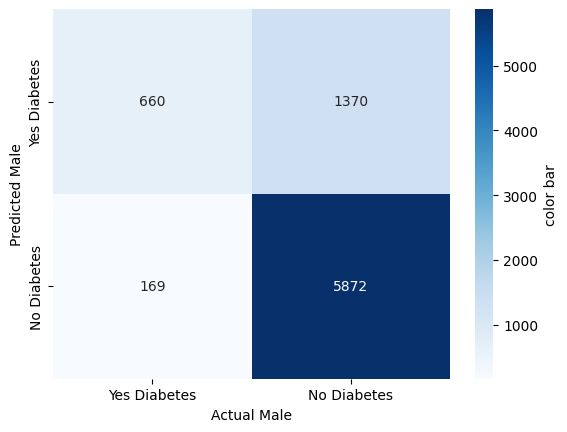


              precision    recall  f1-score   support

 No Diabetes       0.97      0.81      0.88      7242
    Diabetes       0.33      0.80      0.46       829

    accuracy                           0.81      8071
   macro avg       0.65      0.80      0.67      8071
weighted avg       0.91      0.81      0.84      8071


                                0
Accuracy                 0.809317
Sensitivity              0.796140
Specificity              0.810826
AUC-ROC                  0.899887
Precision (No Diabetes)  0.972024
F1-Score (No Diabetes)   0.884138
Precision (Diabetes)     0.325123
F1-Score (Diabetes)      0.461700



In [12]:
#metrics for males such as confusion matrix and classification report

#y_pred_m = lr_male.predict(X_male_test)
#y_prob_m = lr_male.predict_proba(X_male_test)[:,1]

#same threshold for females for optimal performance
y_prob_m = lr_male.predict_proba(X_male_test)[:, 1]
threshold = 0.1
y_pred_m = (y_prob_m > threshold).astype(int)

#function calling metrics
auc_m = roc_auc_score(y_male_test, y_prob_m)
cm_m = confusion_matrix(y_male_test, y_pred_m,labels=[1, 0])
sensitivity = recall_score(y_male_test, y_pred_m)
specificity = recall_score(y_male_test, y_pred_m, pos_label=0)

#generate heatmap for the confusion matrix using seaborn
sns.heatmap(cm_m.T, cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.xlabel("Actual Male")
plt.ylabel("Predicted Male")
#plt.savefig("05: Heatmap Confusion matrix for Males")
plt.show()

print()

#classification report giving metrics like sensitivity and specificity
print(classification_report(y_male_test, y_pred_m, target_names=['No Diabetes','Diabetes']))

metrics_summary2 = {
    'Accuracy': accuracy_score(y_male_test, y_pred_m),
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc_m,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred_m, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred_m, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred_m, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred_m, pos_label=1)
}

print()

metrics_df_m = pd.DataFrame([metrics_summary2])
print(metrics_df_m.T)
print()

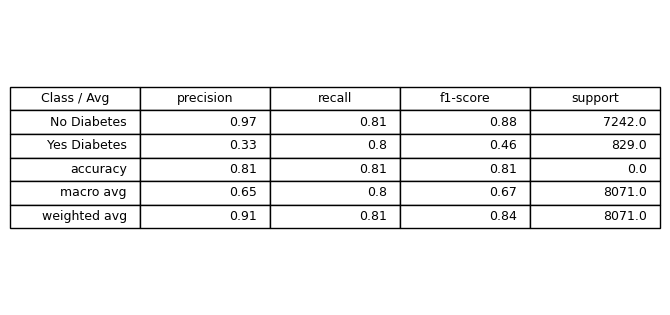

In [13]:
#classification report for males for better presentation

report = classification_report(
    y_male_test, y_pred_m,
    target_names=['No Diabetes', 'Yes Diabetes'],
    output_dict=True
)
df = pd.DataFrame(report).T

row_order = ['No Diabetes', 'Yes Diabetes', 'accuracy', 'macro avg', 'weighted avg']
df = df.reindex([r for r in row_order if r in df.index])

num_cols = [c for c in df.columns if c != 'support']
df[num_cols] = df[num_cols].astype(float).round(2)
if 'support' in df.columns:
    df['support'] = df['support'].astype(int)

fig_h = 1.5 + 0.35 * len(df)         
fig_w = 6.8                           
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis('off')

table_data = np.column_stack([df.index.to_list(), df.values])
col_labels = ['Class / Avg'] + df.columns.to_list()

tbl = ax.table(cellText=table_data, colLabels=col_labels, loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.2)

plt.tight_layout()
#plt.savefig('05: classification_report_males.png', dpi=200, bbox_inches='tight')


Coefficients for both male and female:

In [14]:
#coefficients for each variable in each gender
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False)

,Male,Female
blood_glucose_level,1.357615,1.358492
age,1.065940,1.015786
hypertension,0.797905,0.795987
bmi,0.607536,0.593860
heart_disease,0.567434,0.884498


In [15]:
#merge both metrics summary table into 1
metrics_df3 = pd.concat([metrics_df_m, metrics_df_f], axis=0)
metrics_df3.index = ['Male', 'Female']
metrics_df3.head()

,Accuracy,Sensitivity,Specificity,AUC-ROC,Precision (No Diabetes),F1-Score (No Diabetes),Precision (Diabetes),F1-Score (Diabetes)
Male,0.809317,0.796140,0.810826,0.899887,0.972024,0.884138,0.325123,0.461700
Female,0.850287,0.766029,0.857588,0.910092,0.976904,0.913366,0.317927,0.449357


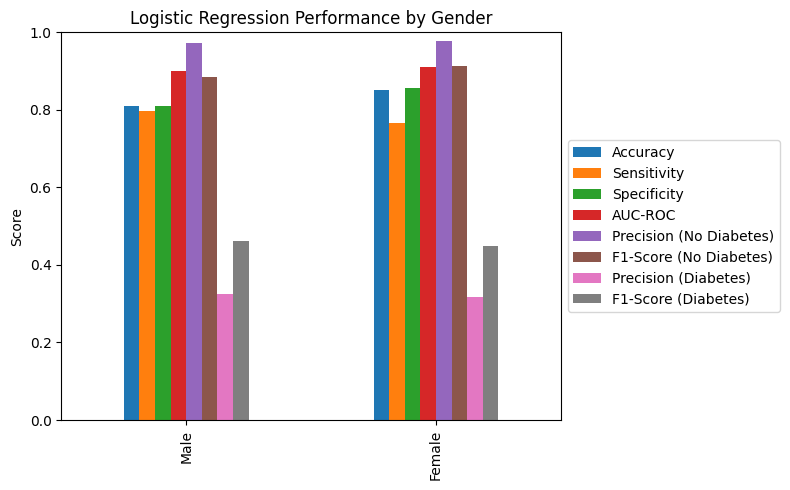

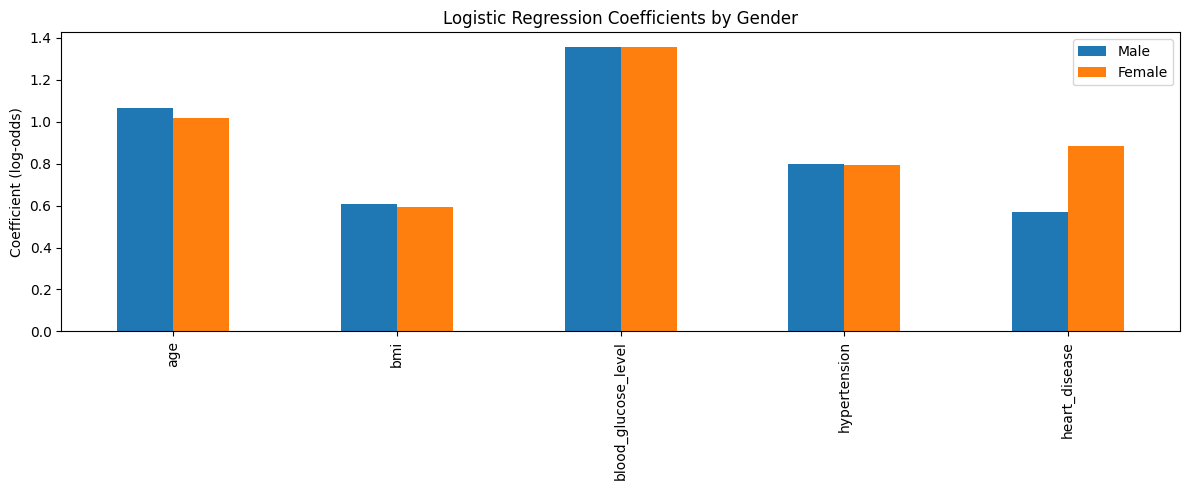

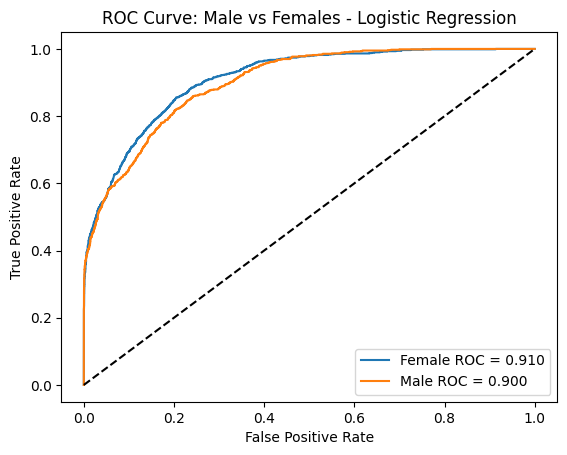

In [16]:
#plots

#performance in logistic regression with the metrics for each gender
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

#coefficients plot for each variable for each gender
coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
#plt.savefig("05: Gender based coefficient plot")

plt.show()

#ROC curve to compare each gender
fpr, tpr, thresholds = roc_curve(y_female_test, y_prob) 
fpr2, tpr2, thresholds2 = roc_curve(y_male_test, y_prob_m) 
plt.plot(fpr, tpr, label=f"Female ROC = {auc_f:.3f}")
plt.plot(fpr2, tpr2, label=f"Male ROC = {auc_m:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Male vs Females - Logistic Regression")
plt.legend()
#plt.savefig("05: ROC Curve Gender based")

plt.show()